In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("c:/Users/layel/Downloads/Credit_card_dataset.csv")   

print(df.shape)
df.head()


(8950, 6)


,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,C10001,0.818182,95.40,201.802084,1000.0,0.000000
1,C10002,0.909091,0.00,4103.032597,7000.0,6442.945483
2,C10003,1.000000,773.17,622.066742,7500.0,0.000000
3,C10004,0.636364,1499.00,0.000000,7500.0,205.788017
4,C10005,1.000000,16.00,678.334763,1200.0,0.000000


In [2]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 non-null   float64
dtypes: float64(5), object(1)
memory usage: 419.7+ KB


,count,mean,std,min,25%,50%,75%,max
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.0,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.0,39.635000,361.280000,1110.130000,49039.57000
PAYMENTS,8950.0,1733.143852,2895.063757,0.0,383.276166,856.901546,1901.134317,50721.48336
CREDIT_LIMIT,8949.0,4494.449450,3638.815725,50.0,1600.000000,3000.000000,6500.000000,30000.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.0,0.000000,0.000000,1113.821139,47137.21176


In [ ]:

df.isna().sum().sort_values(ascending=False).head(20)


df.duplicated().sum()

df["CUST_ID"].nunique()


8950

In [4]:
df = df.drop(columns=["CUST_ID"], errors="ignore")


In [ ]:
num_cols = df.columns
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")  

df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [6]:
def iqr_clip(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k*iqr, q3 + k*iqr
    return s.clip(low, high)

df_clipped = df.copy()
for c in df_clipped.columns:
    df_clipped[c] = iqr_clip(df_clipped[c])


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clipped)


In [ ]:
import matplotlib.pyplot as plt

f1, f2 = "PURCHASES", "CREDIT_LIMIT"

cols_lower = {c.lower(): c for c in df_clipped.columns}
f1 = cols_lower.get(f1.lower(), f1)
f2 = cols_lower.get(f2.lower(), f2)

X2 = df_clipped[[f1, f2]].copy()

X2s = StandardScaler().fit_transform(X2)


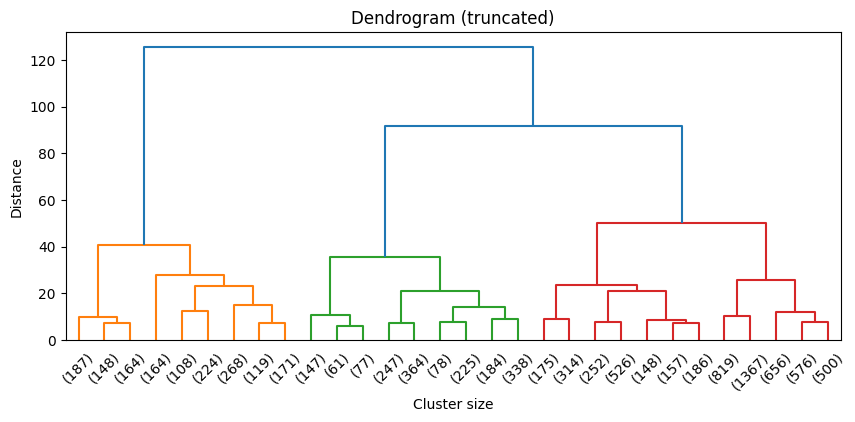

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X2s, method="ward")

plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Dendrogram (truncated)")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()


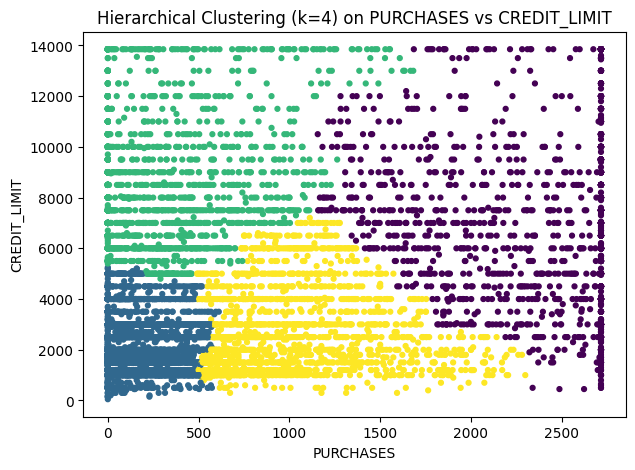

In [ ]:
from sklearn.cluster import AgglomerativeClustering

k_h = 4  
hc = AgglomerativeClustering(n_clusters=k_h, linkage="ward")
labels_h = hc.fit_predict(X2s)

plt.figure(figsize=(7,5))
plt.scatter(X2[f1], X2[f2], c=labels_h, s=12)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title(f"Hierarchical Clustering (k={k_h}) on {f1} vs {f2}")
plt.show()


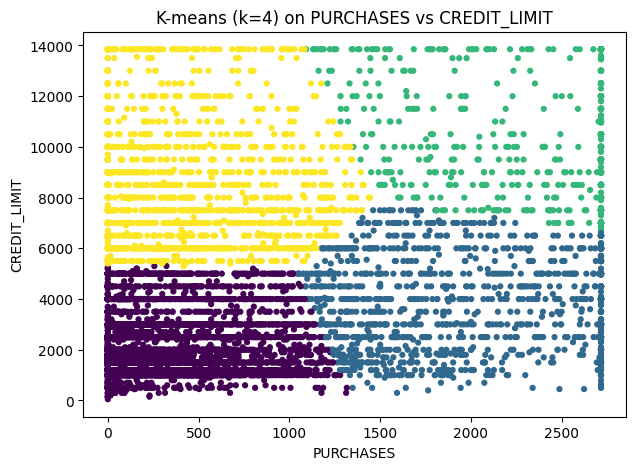

In [11]:
from sklearn.cluster import KMeans

k_km = 4
km = KMeans(n_clusters=k_km, n_init=10, random_state=42)
labels_km = km.fit_predict(X2s)

plt.figure(figsize=(7,5))
plt.scatter(X2[f1], X2[f2], c=labels_km, s=12)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title(f"K-means (k={k_km}) on {f1} vs {f2}")
plt.show()


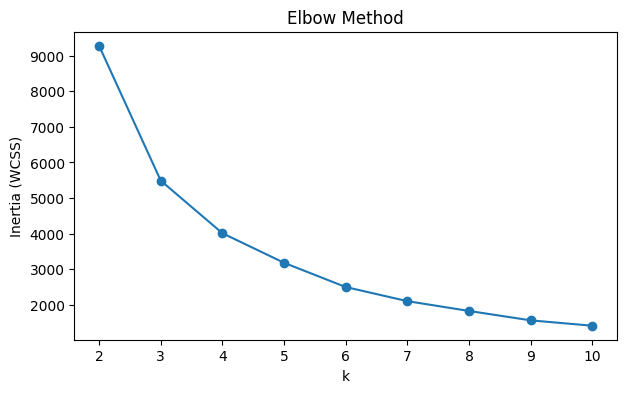

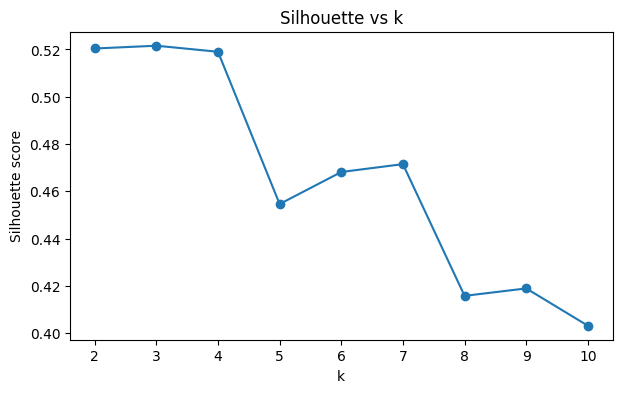

3

In [12]:
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    lab = km.fit_predict(X2s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X2s, lab))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k")
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
best_k


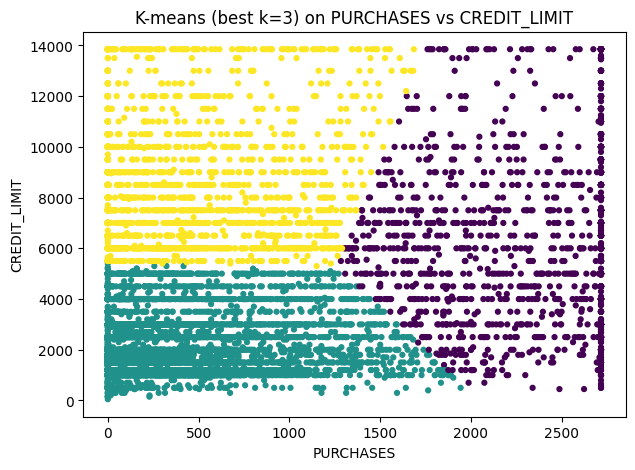

In [13]:
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_best = km_best.fit_predict(X2s)

plt.figure(figsize=(7,5))
plt.scatter(X2[f1], X2[f2], c=labels_best, s=12)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title(f"K-means (best k={best_k}) on {f1} vs {f2}")
plt.show()


In [14]:
seg2 = X2.copy()
seg2["cluster"] = labels_best

seg2.groupby("cluster")[[f1, f2]].agg(["mean", "median", "count"])


PURCHASES                 CREDIT_LIMIT              
                mean    median count         mean  median count
cluster                                                        
0        2368.931109  2696.275  1632  6790.481098  6200.0  1632
1         361.248037   212.845  5446  2325.413861  2000.0  5446
2         408.137885   272.150  1872  8442.846737  7500.0  1872

In [ ]:
from sklearn.cluster import KMeans

km_full = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_full = km_full.fit_predict(X_scaled)

seg_full = df_clipped.copy()
seg_full["cluster"] = labels_full

profile = seg_full.groupby("cluster").mean(numeric_only=True)
counts = seg_full["cluster"].value_counts().sort_index()

counts, profile.head()


(cluster
 0    1751
 1    5498
 2    1701
 Name: count, dtype: int64,
          BALANCE_FREQUENCY    PURCHASES     PAYMENTS  CREDIT_LIMIT  \
 cluster                                                              
 0                 0.968227  2206.281593  2690.162272   7240.756797   
 1                 0.913925   403.245364   657.885813   2929.918474   
 2                 0.950956   304.082551  2192.165159   6328.054798   
 
          CASH_ADVANCE  
 cluster                
 0          339.786032  
 1          241.682621  
 2         2407.325386  )